# Quick-start
In this tutorial we will show 
  * How to initialise the emulator.
  * How to obtain multipoles for the standard $\Lambda$CDM cosmology.

Let’s first import `comet` as well as other required libraries:

In [1]:
from comet import comet
import numpy as np
import matplotlib.pyplot as plt

At initialisation we only need to specify the perturbation theory model that we want to use (valid specifiers are currently either `"EFT"` or `"RS"`; for an overview of the models implemented in COMET, see here) and we can configure COMET either in $\mathrm{Mpc}$ units (`use_Mpc = True`, which is the default option) or in $h^{-1}\mathrm{Mpc}$ units (`use_Mpc = False`). All quantities that are not dimensionless are then returned or assumed to be given in the respective unit system. Let’s define an emulator object for the EFT model using the standard $h^{-1}\mathrm{Mpc}$ units:

In [2]:
EFT=comet(model="EFT", use_Mpc=False)

In order to make predictions for a given cosmological model we first need to specify the fiducial background cosmology, from which the Alcock-Paczynski distortions will be computed. This is done by calling the function `define_fiducial_cosmology` with a dictionary specifying the cosmological parameters and the redshift:

In [3]:
params_fid = {'h':0.695, 'wc':0.11544, 'wb':0.0222191, 'z':0.57}

# This assumes by default a "lambda" cosmology with w0 = -1, for other
# options, see the in-depth examples below.
EFT.define_fiducial_cosmology(params_fid=params_fid)

The function `Pell`, which returns the power spectrum multipoles takes generally three parameters:

1. The scales for which to compute the multipoles (in the corresponding units)
2. A parameter dictionary, specifying cosmological, bias, and (if applicable) additional redshift-space distortions parameters
3. The multipole number, i.e. ell = 0, 2, 4, or a list of multipole numbers

The parameter dictionary must include all shape parameters: the physical cold dark matter and baryon densities (`wc` and `wb`) and the scalar spectral index (`ns`). In case of a flat $\Lambda$CDM model we also need to specify values for $h$ (`h`), the amplitude of scalar fluctuations (`As`) and redshift (`z`). For other cosmologies, see In-depth options for obtaining multipoles.

In [4]:
# Let's create a parameter dictionary
params = {}

# We always need to specify the shape parameter values, e.g.
params['wc'] = 0.11544
params['wb'] = 0.0222191
params['ns'] = 0.9632

# For a LCDM cosmology, we also need:
params['h']  = 0.8
params['As'] = 2.3
params['z']  = 0.6

Finally, we define the values of the bias parameters. The complete list of parameters along with a brief explanation and their dictionary keywords can be found here. In the following we only specify values for the linear and quadratic bias, all other parameters are automatically set to zero:

In [5]:
params['b1'] = 2.
params['b2'] = -0.5

Now, let’s compute the monopole (`ell=0`), quadrupole (`ell=2`) and hexadecapole (`ell=4`) for a range of scales from $0.001 h\,\mathrm{Mpc}^{−1}$ to $0.3h\,\mathrm{Mpc}^{−1}$:

In [6]:
k_hMpc = np.logspace(-3,np.log10(0.3),100)
Pell_LCDM = EFT.Pell(k_hMpc, params, ell=[0,2,4], de_model='lambda')

The output of `Pell` is given in a dictionary format:

In [7]:
print(Pell_LCDM.keys())

dict_keys(['ell0', 'ell2', 'ell4'])


So we can access our results and plot them as follow.

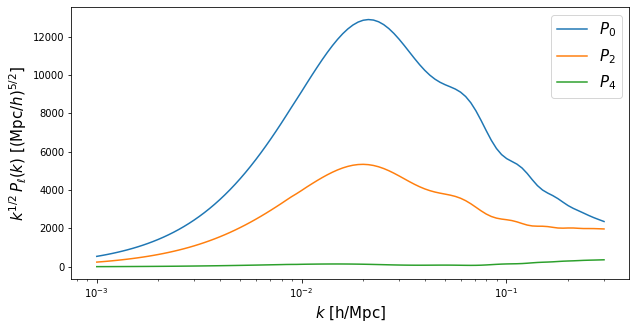

In [8]:
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(111)
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell0"],c='C0',ls='-',label='$P_0$')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell2"],c='C1',ls='-',label='$P_2$')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell4"],c='C2',ls='-',label='$P_4$')
ax.set_xlabel('$k$ [h/Mpc]',fontsize=15)
ax.set_ylabel(r'$k^{1/2}\,P_{\ell}(k)$ [$(\mathrm{Mpc}/h)^{5/2}$]',fontsize=15)
ax.legend(fontsize=15)
plt.show()

# Exploring a few in-depth options

Let us now consider some of the more detailed options in 'COMET':
   * Specifying fiducial background cosmologies
   * Specifying Alcock-Paczynski parameters
   * Specifying the shot noise normalisation
   * Non-flat and non-$\Lambda$ cosmologies
   * Using the $f$-$\sigma_{12}$ parameter space
   * Options for providing different $k$-scales, float vs np.array vs list and the corresponding outputs
   * Description of the `fixed_cosmo_boost` function, i.e., speedup when just changing bias parameters
   * Using different bases for galaxy bias

## Fiducial background cosmologies

Above, we specified the fiducial background cosmology by setting the values of $h$, $\omega_b$, $\omega_c$ and redshift $z$. Alternatively, we can directly provide the values of the Hubble rate $H_{\rm fid}(z)$ and comoving transverse distance $D_{m,\rm fid}(z)$ as follows:

In [9]:
H_fid = 135    # in units of km/s/(Mpc/h)
Dm_fid = 1490  # in units of Mpc/h

EFT.define_fiducial_cosmology(HDm_fid=[H_fid, Dm_fid])

Note that the units of $H_{\rm fid}(z)$ and $D_{m,\rm fid}(z)$ need to be either in $\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1}$ and $\mathrm{Mpc}$ (if `use_Mpc=True`), or $\mathrm{km}\,\mathrm{s}^{-1}\,(h^{-1}\mathrm{Mpc})^{-1}$ and $h^{-1}\mathrm{Mpc}$ (if `use_Mpc=False`).

Moreover, we stress that `define_fiducial_cosmology` is only used to set the fiducial cosmological parameter values. It cannot be used to set default parameter values for the evaluation of the model.

## Alcock-Paczynski parameters

By default the values of the Alcock-Paczynski parameters, $q_{\parallel}$ and $q_{\perp}$, are computed based on the given cosmological parameters and the fiducial background values for the Hubble rate and comoving transverse distance. These values can be overwritten by explicitly providing the Alcock-Paczynski parameters as an argument to the `Pell` function:

In [10]:
q_para = 1.0
q_perp = 1.0

Pell_LCDM_noAP = EFT.Pell(k_hMpc, params, ell=[0,2,4], de_model='lambda', q_tr_lo=[q_perp,q_para])

This can be useful when one would like to ignore Alcock-Paczynski distortions.

## Shot noise normalisation

By default the shot noise parameters in the power spectrum model are assumed to be given in units of $L^3$ for `NP0` and $L^5$ for `NP20` and `NP22`, where $L = (\mathrm{Mpc})^3$ (`use_Mpc=True`) or $L = (h^{-1}\mathrm{Mpc})^3$ (`use_Mpc=False`). It is possible to define a fixed normalisation scale (i.e., corresponding to the Poisson shot noise $1/\bar{n}$) as follows:

In [11]:
nbar = 1e-3  # in the respective units
EFT.define_nbar(nbar)

In this case `NP0` is dimensionless, while `NP20` and `NP22` have dimension $L^2$.

## Non-flat and non-$\Lambda$ cosmologies

Predictions for non-flat cosmologies can be obtained by simply specifying the curvature density parameter $\Omega_k$ in the parameter dictionary:

In [12]:
params['Ok'] = 0.05

For different dark energy models we need to provide a different `de_model` argument for the `Pell` function. For a non-time varying dark energy equation of state, we set `de_model='w0'`, while for a time-varying equation of state in the $w_0$-$w_a$ parametrisation, we set `de_model='w0wa'`. In those cases we need to specify the corresponding values of $w_0$ and $w_a$ in the parameter dictionary. Let's consider the following example:

In [13]:
params['w0'] = -1.1
params['wa'] = 0.1

Then let's recompute the model by updating the previously set parameter values and compare with the $\Lambda$CDM prediction:

In [15]:
Pell_w0wa = EFT.Pell(k_hMpc, params, ell=[0,2,4], de_model='w0wa')

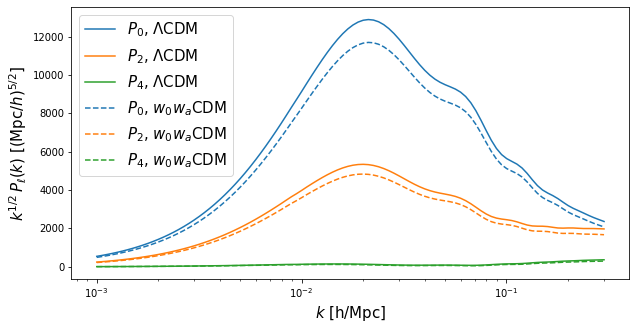

In [16]:
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(111)
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell0"],c='C0',ls='-',label='$P_0$, $\Lambda$CDM')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell2"],c='C1',ls='-',label='$P_2$, $\Lambda$CDM')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell4"],c='C2',ls='-',label='$P_4$, $\Lambda$CDM')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_w0wa["ell0"],c='C0',ls='--',label='$P_0$, $w_0 w_a$CDM')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_w0wa["ell2"],c='C1',ls='--',label='$P_2$, $w_0 w_a$CDM')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_w0wa["ell4"],c='C2',ls='--',label='$P_4$, $w_0 w_a$CDM')
ax.set_xlabel('$k$ [h/Mpc]',fontsize=15)
ax.set_ylabel(r'$k^{1/2}\,P_{\ell}(k)$ [$(\mathrm{Mpc}/h)^{5/2}$]',fontsize=15)
ax.legend(fontsize=15)
plt.show()

## The $f$-$\sigma_{12}$ parameter space

When calling the `Pell` function for a specific dark energy model, it ignores any potential values of `s12`, `q_tr`, `q_lo` and `f` in the parameter dictionary and instead converts the $\Lambda$CDM parameters to the $\sigma_{12}$ parameter space. The internal values of those parameters (which can be accessed via `EFT.params`) have therefore been updated:

In [17]:
# s12, q_tr, q_lo and f are computed internally!
EFT.params

{'wc': 0.11544,
 'wb': 0.0222191,
 'ns': 0.9632,
 's12': 0.5644811904905519,
 'f': 0.7025465611424653,
 'b1': 2.0,
 'b2': -0.5,
 'g2': 0.0,
 'g21': 0.0,
 'c0': 0.0,
 'c2': 0.0,
 'c4': 0.0,
 'cnlo': 0.0,
 'NP0': 0.0,
 'NP20': 0.0,
 'NP22': 0.0,
 'NB0': 0.0,
 'MB0': 0.0,
 'h': 0.8,
 'As': 2.3,
 'Ok': 0.05,
 'w0': -1.1,
 'wa': 0.1,
 'z': 0.6,
 'q_tr': 1.081799699202137,
 'q_lo': 1.045999542223697}

If we want to use the $f$-$\sigma_{12}$ parameter space directly, we need to provide explicit values for `s12`, `f`, `q_lo` ($q_{\parallel}$) and `q_tr` ($q_{\perp}$). As an example, let's redefine our parameter values:

In [18]:
# For predictions using the RSD parameter space we also need to specify values for the following four parameters, e.g.
params['s12']  = 0.6
params['q_lo'] = 1.1
params['q_tr'] = 0.9
params['f']    = 0.7

_Note: When computing the multipoles using the $\sigma_{12}$ parameter space and in $h^{-1}\mathrm{Mpc}$ units, we need to specify a fiducial value for the Hubble rate (provided in the parameter dictionary). This is required to convert the native emulator output from Mpc to Mpc/h units._

In [19]:
Pell_s12 = EFT.Pell(k_hMpc, params, ell=[0,2,4])

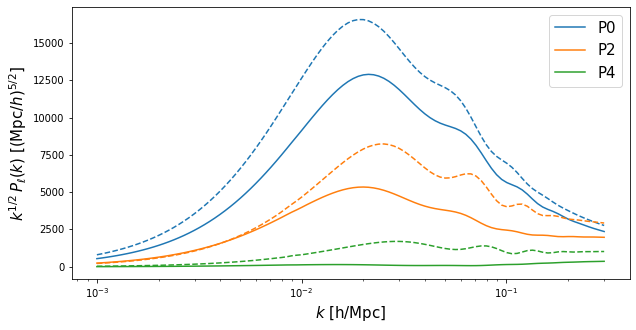

In [20]:
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(111)
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell0"],c='C0',ls='-',label='P0')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell2"],c='C1',ls='-',label='P2')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell4"],c='C2',ls='-',label='P4')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_s12["ell0"],c='C0',ls='--')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_s12["ell2"],c='C1',ls='--')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_s12["ell4"],c='C2',ls='--')
ax.set_xlabel('$k$ [h/Mpc]',fontsize=15)
ax.set_ylabel(r'$k^{1/2}\,P_{\ell}(k)$ [$(\mathrm{Mpc}/h)^{5/2}$]',fontsize=15)
ax.legend(fontsize=15)
plt.show()

## Providing different $k$-scales

There are multiple options for specifying the scales for which to compute the multipoles: if given as a number or numpy array all specified multipoles will be computed for those scales, if given as a list, however, then the first entry of the list is evaluated for the first multipole, the second for the second multipole, etc.

We can output at a single scale and single multipole number, e.g. for the quadrupole at $k = 0.1\,h\,\mathrm{Mpc}^{-1}$:

In [21]:
EFT.Pell(0.1, params, ell=2)

{'ell2': array([12734.58552054])}

Or for various multipoles and multiple scales:

In [22]:
EFT.Pell(np.array([0.1,0.2,0.3]), params, ell=[0,2,4])

{'ell0': array([21993.36193293,  8421.42627781,  5055.15969128]),
 'ell2': array([12734.58552054,  7163.04358551,  5357.26768927]),
 'ell4': array([3027.98356766, 2244.35964221, 1870.99204263])}

Or at different scales for different multipoles (providing a list of numbers or numpy arrays):

In [23]:
EFT.Pell([np.array([0.1,0.2]),0.3], params, ell=[0,4])

{'ell0': array([21993.36193293,  8421.42627781]),
 'ell4': array([1870.99204263])}

_Note: In this case, the length of the list must match the length of the specified multipoles (`ell`)._

Performance-wise it is advisable to compute all required multipoles and scales via the same function call (i.e., avoid calling `Pell` for individual wavemodes).

## Speedup when changing just bias parameters.

It is a common task to test the models at fixed cosmological parameters, and in that case COMET provides the function `Pell_fixed_cosmo_boost`, which accelerates the model computation. It computes all individual model contributions, which are kept fixed as long as the cosmological parameters are not changed, such that changing the bias parameters only is sped up drastically. In the following cells the diferences on time can be seen, which reflects a speed up of around 3 orders of magnitude.

In [25]:
%timeit EFT.Pell(k_hMpc, params, ell=[0,2,4], de_model="lambda")

5.19 ms ± 8.59 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [26]:
%timeit EFT.Pell_fixed_cosmo_boost(k_hMpc, params, ell=[0,2,4], de_model="lambda")

9.46 µs ± 10.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


_Note: Since the computation of all the individual contributions takes more time than the direct evaluation of the multipoles, this is really only useful at fixed cosmological parameters._

## Using different bases for galaxy bias

By default COMET uses the galaxy bias expansion proposed in Eggemeier et al. (2019), but it is also possible to specify bias parameters of two other bases from:
  * Assassi et al (2014), used e.g. in the analyses by Ivanov et al. (2019)
  * d'Amico et al (2019)
To do so, 

# Beyond $P_{\ell}$ predictions

In the following we demonstrate a number of additional outputs that COMET can provide. Specifically:
  * The linear power spectrum, with and without infra-red resummation
  * The Gaussian covariance matrix for the power spectrum multipoles
  * The tree-level bispectrum multipoles

## Linear power spectrum

The linear power spectrum (no infra-red resummation; simply the emulated CAMB output) can be obtained from the function `PL`, while the linear power spectrum with damped BAO wiggles (infra-red resummation) can be obtained from the function `Pdw` (note: this is not the smooth, no-wiggle power spectrum). The arguments are identical to those of `Pell` with the exception that we no longer need to specify a multipole number. 

In [37]:
k = np.logspace(-3,np.log10(0.4),300)
Pdw = EFT.Pdw(params=params, k=k, de_model='lambda')
PL = EFT.PL(params=params, k=k, de_model='lambda')

Let's plot the ratio of the de-wiggled linear power spectrum over the linear power spectrum:

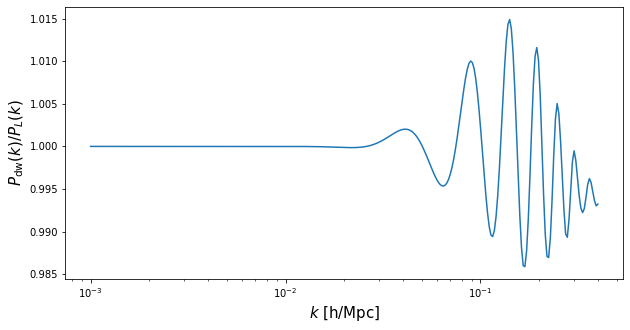

In [41]:
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(111)
ax.semilogx(k, Pdw/PL,c='C0',ls='-')
ax.set_xlabel('$k$ [h/Mpc]',fontsize=15)
ax.set_ylabel(r'$P_{\rm dw}(k)/P_{L}(k)$',fontsize=15)
plt.show()

## Computing covariance matrices

Apart from the multipoles we can also generate (Gaussian) covariance matrices, for which there are again different flags, that are either defined for the $\sigma_{12}$ or the dark energy parameter spaces. The first three arguments, `k`, `params`, and `ell`, are identical to those for `Pell`. In addition, we need to specify a binwidth `dk` and volume (both of which need to be given in the respective units for which the emulator is configured in), for example:

In [49]:
dk_hMpc = 0.005
k_hMpc_lin = np.arange(0.001, 0.3, dk_hMpc)
vol_hMpc = 3e9

In [55]:
Cov_hMpc = EFT.Pell_covariance(k_hMpc_lin, params, ell=[0,2,4], dk=dk_hMpc, volume=vol_hMpc)

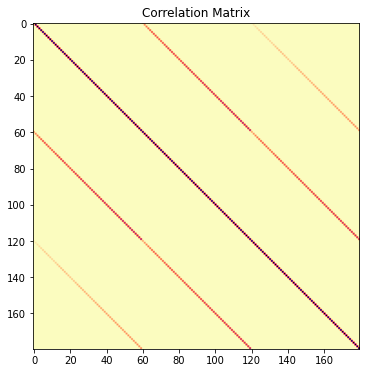

In [56]:
plt.figure(figsize=(9,6))
plt.title(r"")
plt.title(r"Correlation Matrix")
var_inv = np.diag(1./np.sqrt(np.diag(Cov_hMpc)))
R_hMpc = var_inv @ Cov_hMpc @ var_inv
plt.imshow(R_hMpc,cmap='magma_r')
plt.show()

The argument specifying the scales provides the same functionality as for `Pell`, that is, it can either be given as a number or numpy array, in which case all specified multipoles are evaluated for the same scales, or a list of numbers/numpy arrays, in which case the first entry is evaluated for the first multipole in `ell` etc.

For the version with specified dark energy model it is also possible (in addition to providing the volume via the `volume` argument) to provide minimum and maximum redshifts, `zmin` and `zmax`, a sky fraction `fsky`, and a volume scaling factor `volfac` (by default equal to 1), such that the volume is computed in accordance with the given cosmological model. For example:

In [25]:
Cov_hMpc_LCDM = EFT.Pell_covariance(
                        k_hMpc, 
                        params, 
                        ell=[0,2,4],
                        dk=2*np.pi/3780, 
                        zmin=params['z']-0.1, 
                        zmax=params['z']+0.1, 
                        fsky=15000./(360**2/np.pi), 
                        volfac=1, 
                        de_model="lambda", 
                        volume=3780**3
                )

As a further extension, in the case when using measurements from a periodic box that have been averaged over different lines of sight, we have added the averaging corrections for the covariance matrix. We have created the flags `avg_cov` (set to `False` by default) and `avg_los` (set to 3 by default) for the `Pell_covariance` function, so that when `avg_cov=True` it by default will compute the average along the three perpendicular axes (x,y,z), but it is also possible to average over just 2 directions. Note that this computation is quite slow since it involves a different  integral for each k-bin, it may be optimised in the future.

## Tree-level bispectrum

COMET can also output the tree-level bispectrum (in real-space, for the `RS` model) and its multipoles (in redshift-space, for the `EFT` model). These predictions are not emulated, but computed from the emulated de-wiggled power spectrum directly. For that purpose we provide the function `Bell` and in order to demonstrate its usage let's first generate a set of triangle configurations:

In [58]:
k_hMpc_lin = np.arange(0.005, 0.3, 0.005)
tri =[]
for i1,k1 in enumerate(k_hMpc_lin):
    for i2,k2 in enumerate(k_hMpc_lin[:i1+1]):
        for i3,k3 in enumerate(k_hMpc_lin[:i2+1]):
            if k2 + k3 >= k1:
                tri.append([k1, k2, k3])
tri=np.asarray(tri)

The `Bell` function has the same arguments and functionality as the analogous `Pell` function for the power spectrum. However, it expects the triangle configurations to be always specified as a numpy array containing $k_1$, $k_2$, $k_3$ (it is not possible to evaluate the multipoles for different triangles at the moment), and in addition it includes the argument `kfun`, which is used for compressing the number of unique k-modes and is ideally chosen as a value that corresponds closely to the spacing between configurations (e.g. the bin-width for measured data), but must not be much larger. If in doubt, use a value much smaller than the typical spacing. 

In [79]:
params['h'] = 0.69
params['z'] = 0.57
Bell = EFT.Bell(tri, params=params, ell=[0,2,4], de_model='lambda', kfun=0.005)

_Note: The very first call of `Bell` for a given set of configurations can take a little longer (depending on the total number of triangle configurations) as some lookup-tables are generated. All subsequent calls, even with changing cosmological parameters, are then much faster. That implicitly means that one should avoid calling `Bell` multiple times with different triangle configurations, but once for all triangle configurations._

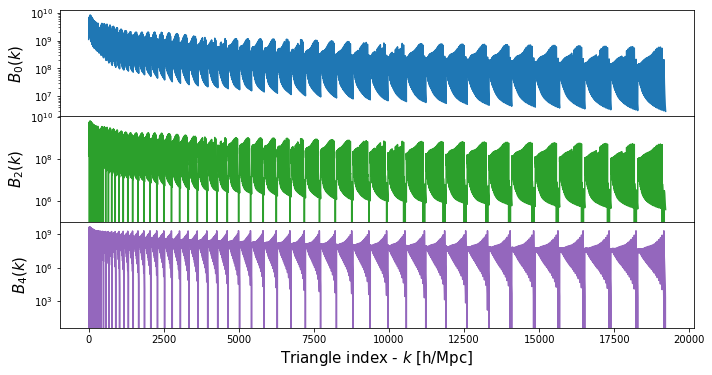

In [71]:
fig, axs = plt.subplots(3,1, figsize=(10,5), sharex=True,)
for i in range(3):
    axs[i].semilogy(np.arange(tri.shape[0]), Bell["ell"+str(2*i)],c='C'+str(2*i),ls='-')
    axs[i].set_ylabel(f'$B_{i*2}(k)$',fontsize=15)

fig.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
axs[-1].set_xlabel('Triangle index - $k$ [h/Mpc]',fontsize=15)
plt.show()

# Working with data sets

## Loading data

We can load measurements of the power spectrum and bispectrum multipoles into COMET using the `define_data_set` function. This function takes first an identifier for the data set (`obs_id`; this can be anything, it will be used to reference the data) and any one of the following arguments:
   * `stat`. Can either be `'powerspectrum'` or `'bispectrum'`; if not provided, `stat` is deduced from the number of columns in `bins` (see below).
   * `bins`. In case of the power spectrum: 1d-array of k-modes corresponding to the measurements; in case of the bispectrum: 2d-array with three columns corresponding to the triangle configuration ($k_1$, $k_2$, $k_3$) of the measurements.
   * `signal`. The measurements of the power spectrum or bispectrum; the size of the first dimension must match the size of `bins`, and it is assumed that the first column corresponds to the monopole, the second to the quadrupole, and the third to the hexadecapole (one does not need to provide all three multipoles, i.e., one can provide only the monopole, or monopole + quadrupole, but one cannot leave out preceding multipoles).
   * `cov`. The covariance matrix of the measurements, which must match the combined size of all given multipoles. If the dimension of `cov` is one-dimensional, it is assumed to be the diagonal of the covariance matrix.
   * `theory_cov`. A flag that specifies whether the given covariance matrix was derived analytically or from a set of simulation measurements. In the latter case an Anderson-Hartlap correction is applied to the inverse, based on `n_realizations`.
   * `n_realizations`. Number of realizations from which the covariance matrix was estimated, only used (and required) in case `theory_cov=False`.

Let us load some mock power spectrum measurements:

In [101]:
data = np.loadtxt('mock_Pk_mean.dat')
Cov = np.loadtxt('mock_Pk_cov.dat')

k = data[:,0]
P0 = data[:,1]
P2 = data[:,3]
P4 = data[:,5]

In [112]:
# Let's call this data set 'mock_Pk'
EFT.define_data_set(obs_id='mock_Pk', bins=k, signal=np.array([P0,P2,P4]).T, cov=Cov, theory_cov=False, n_realizations=300)

We can access the data through `EFT.data['mock_Pk']` and check, for example, that the type of statistic was correctly identified (since it was provided above):

In [113]:
EFT.data['mock_Pk'].stat

'powerspectrum'

## Computing the $\chi^2$

Finally, we can let COMET directly compute $\chi^2$ values based on the provided data set, a given set of model parameters and range of scales. 

To do so, we call the function `chi2`, which takes as arguments the identifier of the data set, the parameter dictionary, a maximum k-mode value `kmax`, a model argument `de_model`. `kmax` can either be a number, in which case the same cutoff is applied for all multipoles, or a list of numbers for each individual multipole, as for the multipoles case. If the cutoff is zero (or smaller than the minimum scale of the observations) for a particular multipole, then it is excluded from the computation of the chi-square. `kmax` is also assumed to be in the units of the emulator. `de_model` can be one of the options specified before. 

In [116]:
EFT.chi2(obs_id='mock_Pk',params=params, kmax=[0.30, 0.30, 0.30], de_model='lambda', chi2_decomposition=False)

6754.176546673202

Moreover, in order to speed up the computation of the $\chi^2$, in the same way as `Pell_fixed_cosmo_boost` function, we can specify the flag `chi2_decomposition` in order to avoid recompute the cosmological dependent quantities. Let's see how it works

In [117]:
%timeit EFT.chi2(obs_id='mock_Pk',params=params, kmax=[0.30, 0.30, 0.30], de_model='lambda', chi2_decomposition=False)

6.37 ms ± 153 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [118]:
%timeit EFT.chi2(obs_id='mock_Pk',params=params, kmax=[0.30, 0.30, 0.30], de_model='lambda', chi2_decomposition=True)

9.11 µs ± 20.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
